# 🛍️ Mall Customer Segmentation: AI/ML Learning + Data-Driven Product Strategy

**Creator:** Phyo Thaw  
**Project Type:** Beginner-friendly AI/ML notebook + employer-facing product analytics case study  
**Target Audience:** Students learning AI/ML and employers looking for data-driven product owner capability.

## Project Summary
This notebook segments mall customers using clustering and translates the results into product and marketing decisions.

## Business Problem
Customer segmentation helps product and marketing teams understand which customer groups are high-value, price-sensitive, inactive, or suitable for premium campaigns.

## Machine Learning Problem
This is an **unsupervised learning** project. We do not predict a target label. Instead, clustering algorithms discover natural customer groups from the data.

# 1. Import Libraries
We use beginner-friendly libraries for data analysis, visualization, clustering, evaluation, and dimensionality reduction.

In [4]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42

# 2. Load Dataset — Kaggle Friendly
This cell works in Kaggle when the dataset is attached under `/kaggle/input`. It also works locally if `Mall_Customers.csv` is in the same folder.

In [5]:
# Kaggle-friendly loading function
possible_paths = [
    "/kaggle/input/customer-segmentation-tutorial-in-python/Mall_Customers.csv",
    "/kaggle/input/mall-customers/Mall_Customers.csv",
    "Mall_Customers.csv"
]

dataset_path = None

for path in possible_paths:
    if os.path.exists(path):
        dataset_path = path
        break

if dataset_path is None:
    try:
        import kagglehub
        kaggle_path = kagglehub.dataset_download("vjchoudhary7/customer-segmentation-tutorial-in-python")
        dataset_path = os.path.join(kaggle_path, "Mall_Customers.csv")
    except Exception as e:
        raise FileNotFoundError(
            "Dataset not found. Please add the Kaggle dataset or place Mall_Customers.csv in the notebook folder."
        )

df = pd.read_csv(dataset_path)
print("Dataset loaded from:", dataset_path)
df.head()

Dataset loaded from: /Users/diazphyo/.cache/kagglehub/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/versions/1/Mall_Customers.csv


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# 3. First Look at the Dataset
We inspect shape, data types, missing values, duplicated rows, and basic statistics.

In [6]:
print("Dataset shape:", df.shape)
df.info()

Dataset shape: (200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [7]:
display(df.head())
display(df.describe())

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [8]:
quality_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df) * 100).round(2),
    "Unique Values": df.nunique(),
    "Data Type": df.dtypes
})
quality_summary

,Missing Values,Missing %,Unique Values,Data Type
CustomerID,0,0.0,200,int64
Gender,0,0.0,2,object
Age,0,0.0,51,int64
Annual Income (k$),0,0.0,64,int64
Spending Score (1-100),0,0.0,84,int64


In [9]:
print("Duplicated rows:", df.duplicated().sum())

Duplicated rows: 0


## Student Learning Note
Good machine learning does not start with models. It starts with understanding whether the data is suitable for the problem.

# 4. Clean Column Names
The original dataset has long column names. We rename them into simple snake_case names for cleaner code.

In [10]:
df = df.rename(columns={
    "CustomerID": "customer_id",
    "Gender": "gender",
    "Age": "age",
    "Annual Income (k$)": "annual_income_k",
    "Spending Score (1-100)": "spending_score"
})
df.head()

,customer_id,gender,age,annual_income_k,spending_score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# 5. Exploratory Data Analysis — Understanding Customers
This EDA is intentionally kept because it supports both learning and business storytelling.

## 5.1 Gender Distribution
Business question: What is the gender composition of customers?

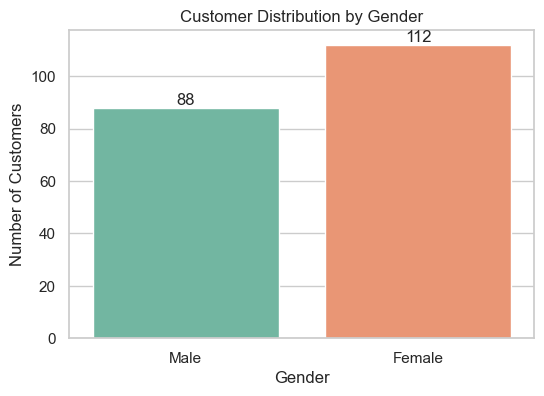

In [11]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x="gender", hue="gender", palette="Set2", legend=False)
plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
for container in ax.containers:
    ax.bar_label(container)
plt.show()

## 5.2 Distribution of Age, Income, and Spending Score
Business question: What kind of customers does the mall attract?

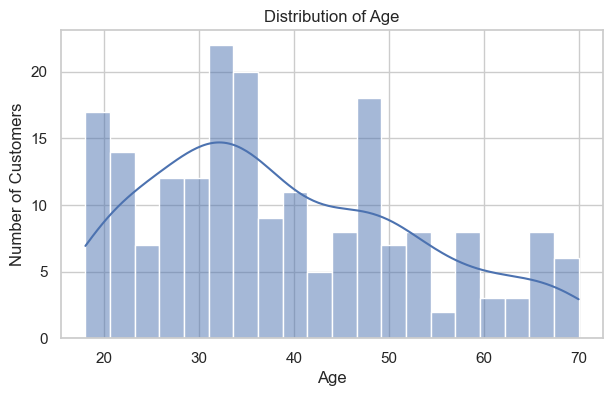

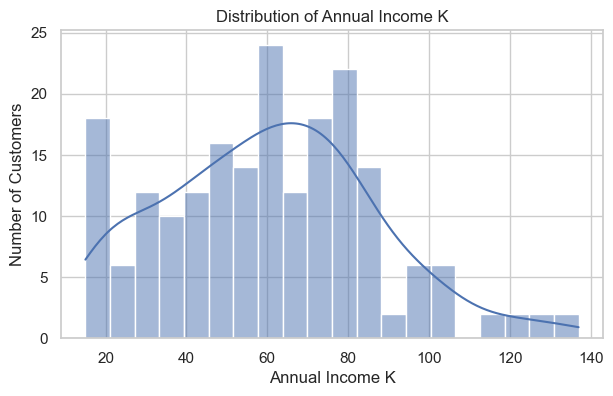

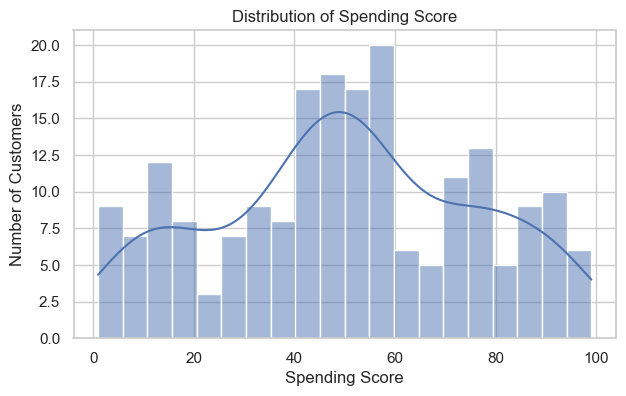

In [12]:
numeric_cols = ["age", "annual_income_k", "spending_score"]
for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f"Distribution of {col.replace('_', ' ').title()}")
    plt.xlabel(col.replace('_', ' ').title())
    plt.ylabel("Number of Customers")
    plt.show()

## 5.3 Outlier Check
K-Means is distance-based and can be affected by outliers.

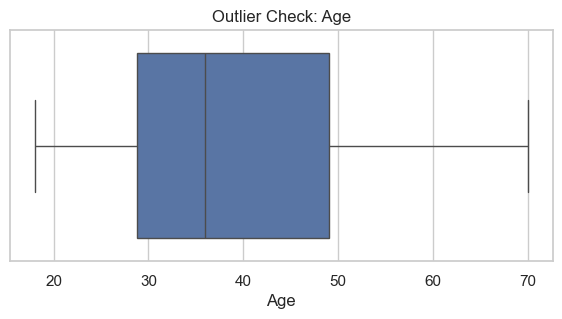

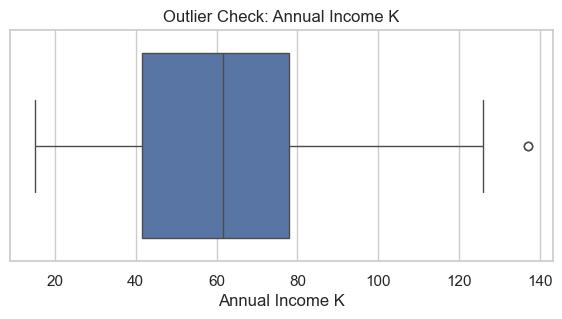

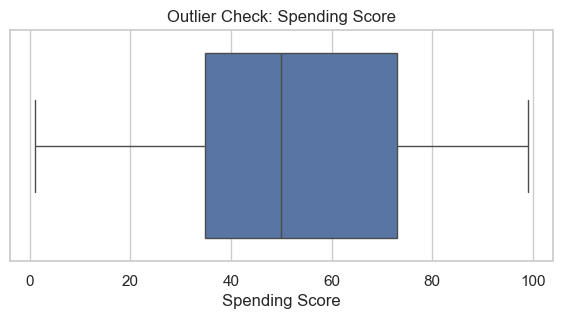

In [13]:
for col in numeric_cols:
    plt.figure(figsize=(7, 3))
    sns.boxplot(data=df, x=col)
    plt.title(f"Outlier Check: {col.replace('_', ' ').title()}")
    plt.xlabel(col.replace('_', ' ').title())
    plt.show()

## 5.4 Income vs Spending Score
This is the most important business visualization because it shows possible customer segments.

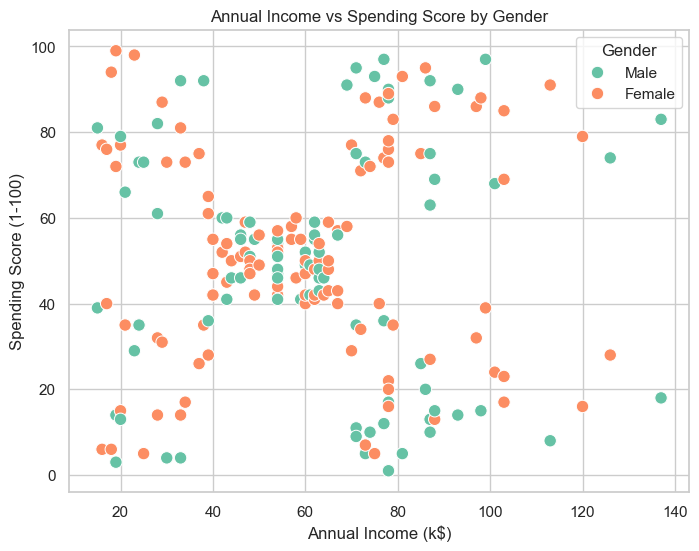

In [14]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="annual_income_k", y="spending_score", hue="gender", palette="Set2", s=80)
plt.title("Annual Income vs Spending Score by Gender")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Gender")
plt.show()

## 5.5 Age vs Spending Score
Business question: Are younger or older customers more active spenders?

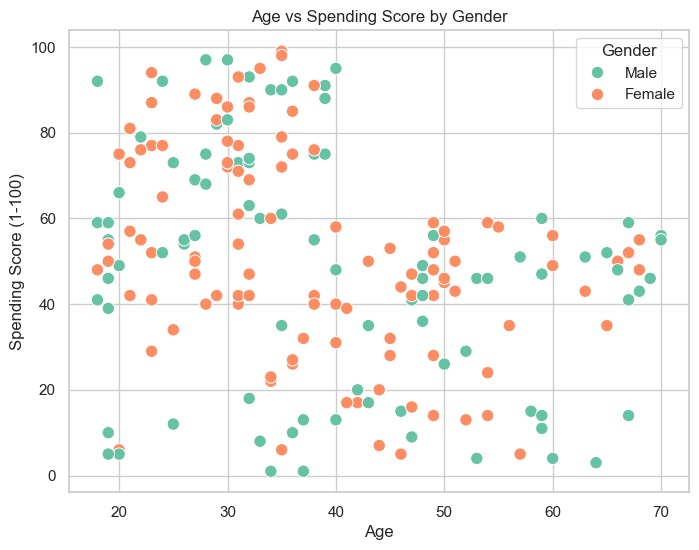

In [15]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="age", y="spending_score", hue="gender", palette="Set2", s=80)
plt.title("Age vs Spending Score by Gender")
plt.xlabel("Age")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Gender")
plt.show()

## 5.6 Correlation Heatmap

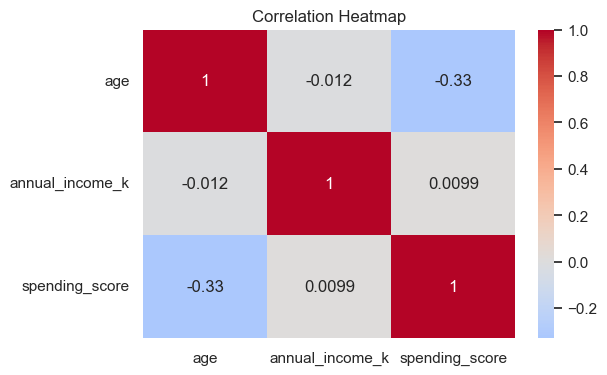

In [16]:
plt.figure(figsize=(6, 4))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

## EDA Interpretation
The most useful features are annual income, spending score, and age. The income vs spending plot suggests natural groups such as high-income high-spending customers, high-income low-spending customers, and balanced mainstream customers.

# 6. Feature Engineering
We create business-friendly features for interpretation: age group, income group, spending group, income-spending ratio, and spending efficiency.

In [17]:
df_fe = df.copy()

age_bins = [0, 25, 35, 50, 100]
age_labels = ["Young", "Young Adult", "Adult", "Senior"]
df_fe["age_group"] = pd.cut(df_fe["age"], bins=age_bins, labels=age_labels)

income_bins = [0, 40, 70, 140]
income_labels = ["Low Income", "Middle Income", "High Income"]
df_fe["income_group"] = pd.cut(df_fe["annual_income_k"], bins=income_bins, labels=income_labels)

spending_bins = [0, 40, 70, 100]
spending_labels = ["Low Spending", "Medium Spending", "High Spending"]
df_fe["spending_group"] = pd.cut(df_fe["spending_score"], bins=spending_bins, labels=spending_labels)

df_fe["income_spending_ratio"] = df_fe["annual_income_k"] / (df_fe["spending_score"] + 1)
df_fe["spending_efficiency"] = df_fe["spending_score"] / (df_fe["annual_income_k"] + 1)

df_fe.head()

,customer_id,gender,age,annual_income_k,spending_score,age_group,income_group,spending_group,income_spending_ratio,spending_efficiency
0,1,Male,19,15,39,Young,Low Income,Low Spending,0.375000,2.437500
1,2,Male,21,15,81,Young,Low Income,High Spending,0.182927,5.062500
2,3,Female,20,16,6,Young,Low Income,Low Spending,2.285714,0.352941
3,4,Female,23,16,77,Young,Low Income,High Spending,0.205128,4.529412
4,5,Female,31,17,40,Young Adult,Low Income,Low Spending,0.414634,2.222222


## 6.1 Business View of Engineered Features

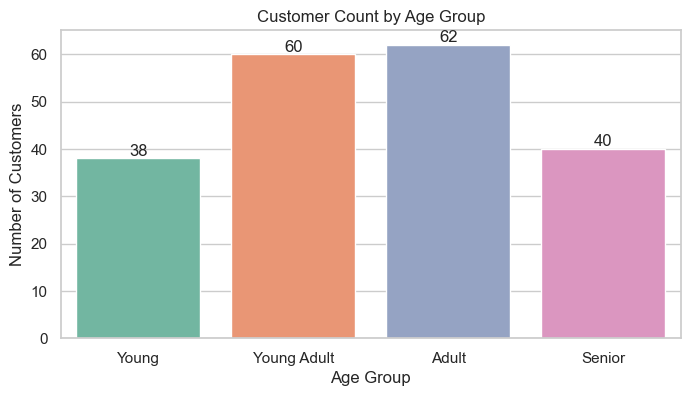

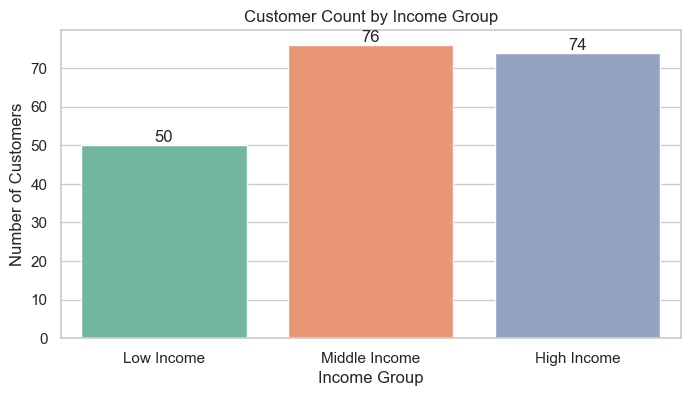

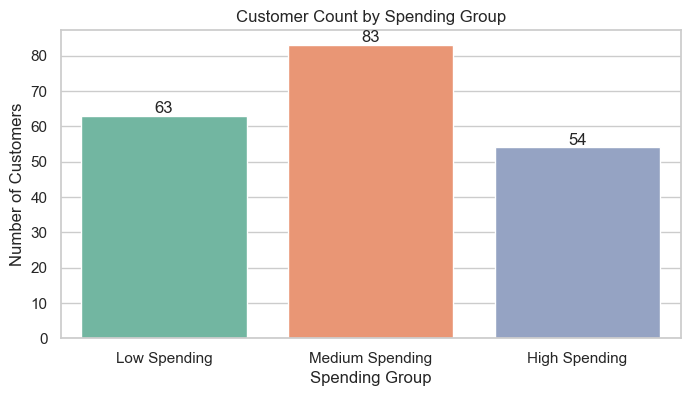

In [18]:
for col in ["age_group", "income_group", "spending_group"]:
    plt.figure(figsize=(8, 4))
    ax = sns.countplot(data=df_fe, x=col, hue=col, palette="Set2", legend=False)
    plt.title(f"Customer Count by {col.replace('_', ' ').title()}")
    plt.xlabel(col.replace('_', ' ').title())
    plt.ylabel("Number of Customers")
    for container in ax.containers:
        ax.bar_label(container)
    plt.show()

# 7. Feature Selection for Clustering
We use age, annual income, and spending score. Customer ID is excluded because it is only an identifier.

In [19]:
features = ["age", "annual_income_k", "spending_score"]
X = df_fe[features].copy()
X.head()

,age,annual_income_k,spending_score
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


# 8. Feature Scaling
Clustering algorithms are distance-based. Scaling prevents one feature from dominating the distance calculation.

In [20]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)
X_scaled_df.head()

,age,annual_income_k,spending_score
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


# 9. Finding the Best Number of Clusters
We compare inertia, silhouette score, Davies-Bouldin index, and Calinski-Harabasz score.

In [21]:
inertias, silhouette_scores, dbi_scores, ch_scores = [], [], [], []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    dbi_scores.append(davies_bouldin_score(X_scaled, labels))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))

cluster_eval_df = pd.DataFrame({
    "k": list(k_values),
    "Inertia": inertias,
    "Silhouette Score": silhouette_scores,
    "Davies-Bouldin Index": dbi_scores,
    "Calinski-Harabasz Score": ch_scores
})
cluster_eval_df

,k,Inertia,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score
0,2,389.386189,0.335472,1.260682,107.095567
1,3,295.212246,0.357793,1.050270,101.694947
2,4,205.225147,0.403958,0.930796,125.676397
3,5,168.247580,0.416643,0.874551,125.100940
4,6,133.868421,0.428417,0.825354,135.102104
5,7,117.011555,0.417232,0.793467,132.774309
6,8,103.873292,0.408207,0.891783,131.006216
7,9,93.092891,0.417693,0.819844,130.003560
8,10,82.385154,0.406554,0.867904,132.638273


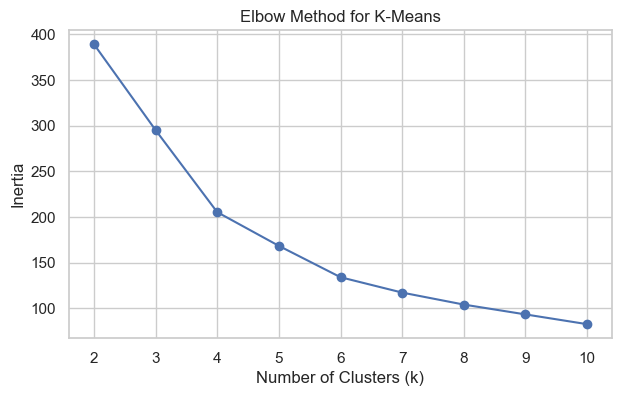

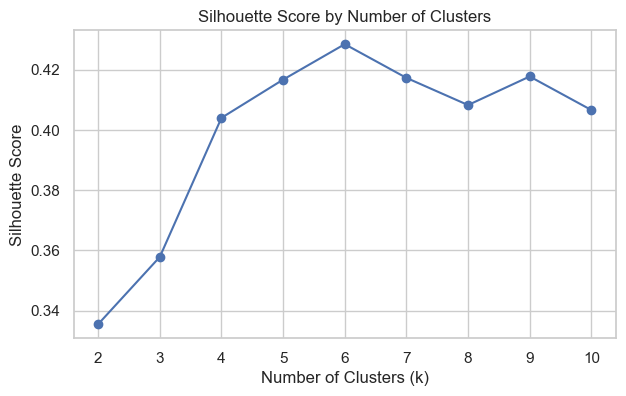

In [22]:
plt.figure(figsize=(7, 4))
plt.plot(cluster_eval_df["k"], cluster_eval_df["Inertia"], marker="o")
plt.title("Elbow Method for K-Means")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(cluster_eval_df["k"], cluster_eval_df["Silhouette Score"], marker="o")
plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.show()

## Choosing k
We select **k = 5** because it is both visually meaningful and business-friendly for this dataset.

# 10. K-Means Clustering

In [23]:
final_k = 5
kmeans = KMeans(n_clusters=final_k, random_state=RANDOM_STATE, n_init=10)
df_fe["cluster_kmeans"] = kmeans.fit_predict(X_scaled)
df_fe[["customer_id", "age", "annual_income_k", "spending_score", "cluster_kmeans"]].head()

,customer_id,age,annual_income_k,spending_score,cluster_kmeans
0,1,19,15,39,1
1,2,21,15,81,1
2,3,20,16,6,0
3,4,23,16,77,1
4,5,31,17,40,1


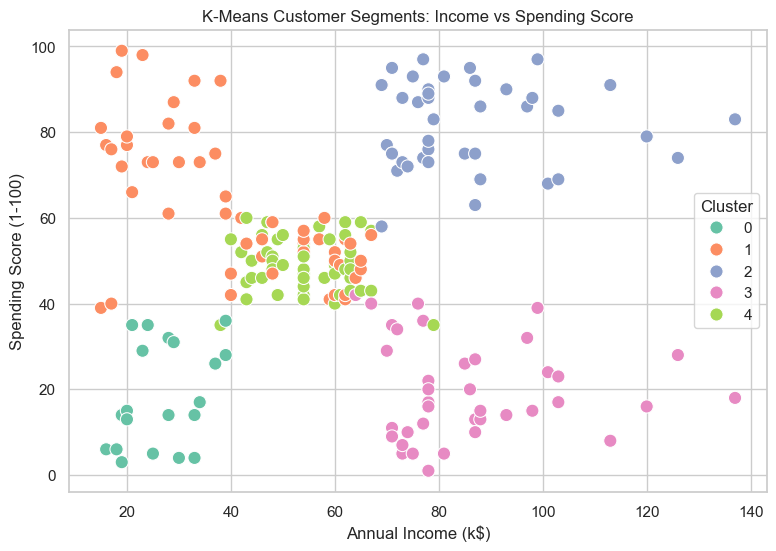

In [24]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df_fe, x="annual_income_k", y="spending_score", hue="cluster_kmeans", palette="Set2", s=90)
plt.title("K-Means Customer Segments: Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Cluster")
plt.show()

# 11. Comparing Different Clustering Algorithms
We compare K-Means, Agglomerative Clustering, Gaussian Mixture, and DBSCAN.

In [25]:
clustering_models = {
    "K-Means": KMeans(n_clusters=5, random_state=RANDOM_STATE, n_init=10),
    "Agglomerative": AgglomerativeClustering(n_clusters=5),
    "Gaussian Mixture": GaussianMixture(n_components=5, random_state=RANDOM_STATE),
    "DBSCAN": DBSCAN(eps=0.7, min_samples=5)
}

comparison_results = []
for name, model in clustering_models.items():
    labels = model.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    if n_clusters > 1:
        comparison_results.append({
            "Model": name,
            "Number of Clusters": n_clusters,
            "Silhouette Score": silhouette_score(X_scaled, labels),
            "Davies-Bouldin Index": davies_bouldin_score(X_scaled, labels),
            "Calinski-Harabasz Score": calinski_harabasz_score(X_scaled, labels)
        })
    else:
        comparison_results.append({
            "Model": name,
            "Number of Clusters": n_clusters,
            "Silhouette Score": np.nan,
            "Davies-Bouldin Index": np.nan,
            "Calinski-Harabasz Score": np.nan
        })

comparison_df = pd.DataFrame(comparison_results).sort_values("Silhouette Score", ascending=False)
comparison_df

,Model,Number of Clusters,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score
0,K-Means,5,0.416643,0.874551,125.100940
1,Agglomerative,5,0.390028,0.916289,107.826560
2,Gaussian Mixture,5,0.376441,0.890168,105.018131
3,DBSCAN,1,NaN,NaN,NaN


### Why DBSCAN performed poorly:
1. DBSCAN is sensitive to the choice of eps and min_samples parameters. If these are not well-tuned, it can lead to poor clustering results, such as labeling most points as noise or creating too many small clusters.
2. The dataset may not have well-defined density-based clusters, which is what DBSCAN relies on. If the data is more suited to centroid-based clustering (like K-Means) or hierarchical clustering, DBSCAN may struggle to find meaningful clusters.
3. DBSCAN can struggle with clusters of varying densities, which may be the case in this dataset. If some clusters are denser than others, DBSCAN may fail to identify the less dense clusters correctly.

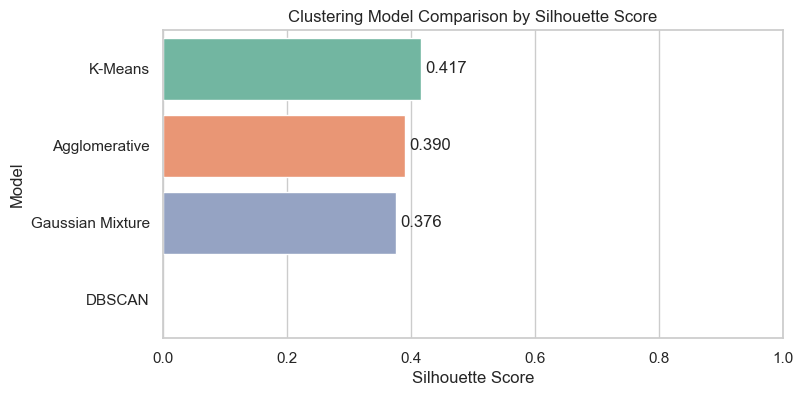

In [26]:
plt.figure(figsize=(8, 4))
ax = sns.barplot(data=comparison_df, x="Silhouette Score", y="Model", hue="Model", palette="Set2", legend=False)
plt.title("Clustering Model Comparison by Silhouette Score")
plt.xlabel("Silhouette Score")
plt.ylabel("Model")
plt.xlim(0, 1)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)
plt.show()

## Model Comparison Interpretation
The best clustering model is not only the one with the highest metric. For product analytics, clusters must be understandable, actionable, and easy to communicate.

# 12. PCA Visualization
PCA reduces the scaled features into two components so we can visualize the clusters.

In [27]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
df_fe["pca_1"] = X_pca[:, 0]
df_fe["pca_2"] = X_pca[:, 1]
print("Explained variance ratio:", pca.explained_variance_ratio_)

Explained variance ratio: [0.44266167 0.33308378]


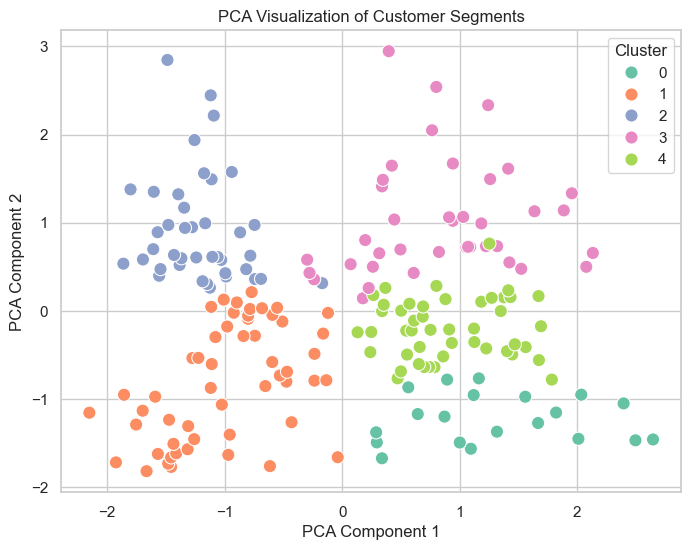

In [28]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_fe, x="pca_1", y="pca_2", hue="cluster_kmeans", palette="Set2", s=90)
plt.title("PCA Visualization of Customer Segments")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster")
plt.show()

# 13. Cluster Profiling
This is where the project becomes useful for product teams. We summarize the behavior of each cluster.

In [29]:
cluster_profile = df_fe.groupby("cluster_kmeans").agg(
    customer_count=("customer_id", "count"),
    avg_age=("age", "mean"),
    avg_income=("annual_income_k", "mean"),
    avg_spending_score=("spending_score", "mean"),
    avg_income_spending_ratio=("income_spending_ratio", "mean"),
    avg_spending_efficiency=("spending_efficiency", "mean")
).round(2)
cluster_profile

,customer_count,avg_age,avg_income,avg_spending_score,avg_income_spending_ratio,avg_spending_efficiency
cluster_kmeans,,,,,,
0,20,46.25,26.75,18.35,2.19,0.66
1,54,25.19,41.09,62.24,0.73,1.93
2,40,32.88,86.10,81.53,1.06,0.96
3,39,39.87,86.10,19.36,7.17,0.23
4,47,55.64,54.38,48.85,1.11,0.91


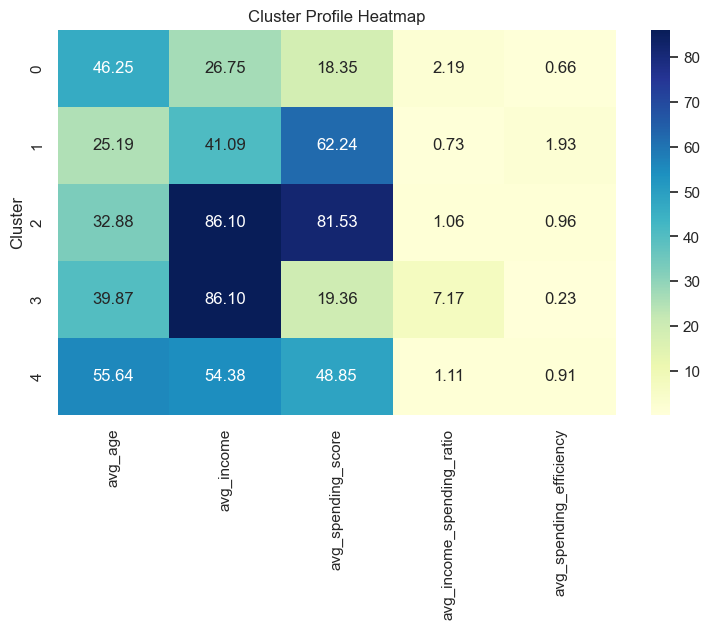

In [30]:
plt.figure(figsize=(9, 5))
sns.heatmap(
    cluster_profile[["avg_age", "avg_income", "avg_spending_score", "avg_income_spending_ratio", "avg_spending_efficiency"]],
    annot=True, cmap="YlGnBu", fmt=".2f"
)
plt.title("Cluster Profile Heatmap")
plt.ylabel("Cluster")
plt.show()

# 14. Business-Friendly Segment Names
Cluster numbers are not meaningful to stakeholders, so we translate customer behavior into business segment names.

In [31]:
def assign_segment_name(row):
    income = row["annual_income_k"]
    spending = row["spending_score"]
    if income >= 70 and spending >= 60:
        return "Premium High-Value Customers"
    elif income >= 70 and spending < 40:
        return "High-Income Low-Spenders"
    elif income < 45 and spending >= 60:
        return "Budget-Conscious Active Spenders"
    elif income < 45 and spending < 40:
        return "Low-Value / Low-Engagement Customers"
    else:
        return "Balanced Mainstream Customers"

df_fe["business_segment"] = df_fe.apply(assign_segment_name, axis=1)
df_fe[["age", "annual_income_k", "spending_score", "cluster_kmeans", "business_segment"]].head(10)

,age,annual_income_k,spending_score,cluster_kmeans,business_segment
0,19,15,39,1,Low-Value / Low-Engagement Customers
1,21,15,81,1,Budget-Conscious Active Spenders
2,20,16,6,0,Low-Value / Low-Engagement Customers
3,23,16,77,1,Budget-Conscious Active Spenders
4,31,17,40,1,Balanced Mainstream Customers
5,22,17,76,1,Budget-Conscious Active Spenders
6,35,18,6,0,Low-Value / Low-Engagement Customers
7,23,18,94,1,Budget-Conscious Active Spenders
8,64,19,3,0,Low-Value / Low-Engagement Customers
9,30,19,72,1,Budget-Conscious Active Spenders


In [32]:
segment_summary = df_fe.groupby("business_segment").agg(
    customer_count=("customer_id", "count"),
    avg_age=("age", "mean"),
    avg_income=("annual_income_k", "mean"),
    avg_spending_score=("spending_score", "mean")
).round(2).sort_values("avg_spending_score", ascending=False)
segment_summary

,customer_count,avg_age,avg_income,avg_spending_score
business_segment,,,,
Premium High-Value Customers,38,32.53,87.00,81.89
Budget-Conscious Active Spenders,25,27.16,27.60,77.08
Balanced Mainstream Customers,78,42.81,55.10,49.90
Low-Value / Low-Engagement Customers,22,45.86,26.73,20.05
High-Income Low-Spenders,37,40.73,87.30,18.05


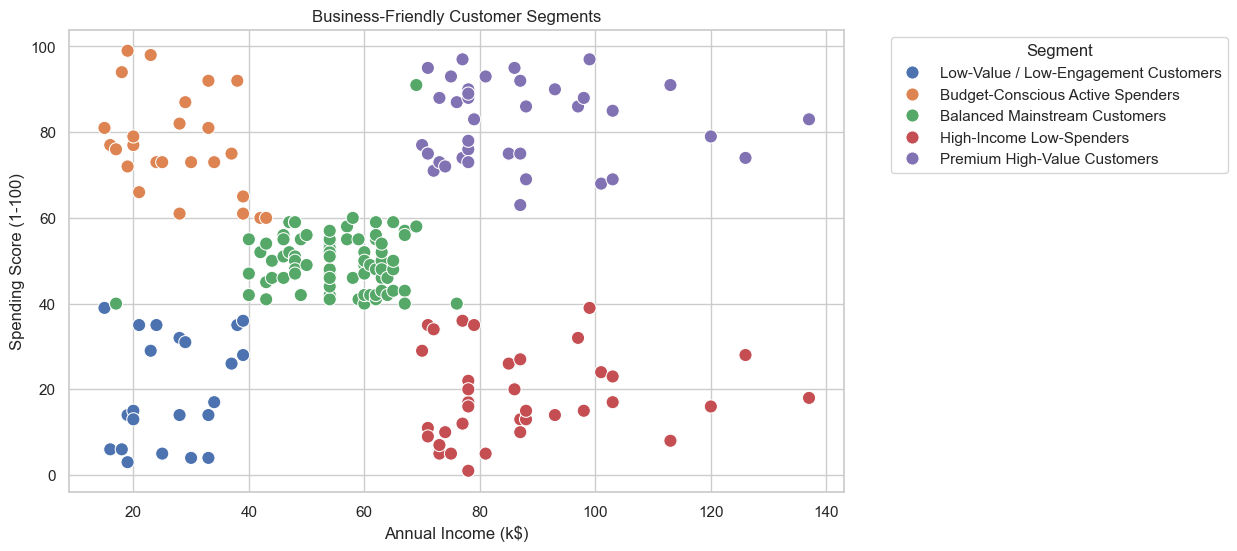

In [33]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_fe, x="annual_income_k", y="spending_score", hue="business_segment", s=90)
plt.title("Business-Friendly Customer Segments")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Segment", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

# 15. Product Owner Recommendations
This section is employer-facing. It shows how analysis becomes product and marketing action.

In [34]:
recommendations = pd.DataFrame({
    "Customer Segment": [
        "Premium High-Value Customers",
        "High-Income Low-Spenders",
        "Budget-Conscious Active Spenders",
        "Low-Value / Low-Engagement Customers",
        "Balanced Mainstream Customers"
    ],
    "Customer Behavior": [
        "High income and high spending score",
        "High income but low spending score",
        "Lower income but active spending behavior",
        "Low income and low spending score",
        "Moderate income and moderate spending"
    ],
    "Product / Marketing Action": [
        "Offer VIP loyalty programs, exclusive bundles, and early access campaigns",
        "Investigate barriers and provide premium personalized offers",
        "Use discounts, bundles, gamified rewards, and value campaigns",
        "Use low-cost engagement campaigns and understand low engagement reasons",
        "Maintain regular campaigns, personalized recommendations, and seasonal offers"
    ],
    "Business Goal": [
        "Retention and lifetime value growth",
        "Conversion and spending activation",
        "Frequency and basket-size growth",
        "Reactivation or low-cost nurturing",
        "Stable revenue and broad engagement"
    ]
})
recommendations

,Customer Segment,Customer Behavior,Product / Marketing Action,Business Goal
0,Premium High-Value Customers,High income and high spending score,"Offer VIP loyalty programs, exclusive bundles,...",Retention and lifetime value growth
1,High-Income Low-Spenders,High income but low spending score,Investigate barriers and provide premium perso...,Conversion and spending activation
2,Budget-Conscious Active Spenders,Lower income but active spending behavior,"Use discounts, bundles, gamified rewards, and ...",Frequency and basket-size growth
3,Low-Value / Low-Engagement Customers,Low income and low spending score,Use low-cost engagement campaigns and understa...,Reactivation or low-cost nurturing
4,Balanced Mainstream Customers,Moderate income and moderate spending,"Maintain regular campaigns, personalized recom...",Stable revenue and broad engagement


## Product Thinking Summary
A data-driven product owner should not stop at model results. The real value is converting analysis into decisions such as loyalty campaigns, activation offers, retention strategies, and A/B testing ideas.

# 16. Student Learning Summary
This project teaches clustering, EDA, scaling, k selection, model comparison, PCA visualization, cluster profiling, and business interpretation.

# 17. Limitations
- The dataset has only 200 customers.
- It lacks transaction history and customer lifetime value.
- It has no time dimension.
- Spending score is simplified and not actual revenue.
- Clusters should be validated with real business experiments.

# 18. Future Improvements
- Add RFM analysis if transaction data is available.
- Build a Streamlit dashboard.
- Test clustering stability.
- Use UMAP or t-SNE visualization.
- Connect clusters to campaign KPIs.
- Design A/B tests for each segment.
- Estimate customer lifetime value.

# 19. Final Conclusion
This project demonstrates how customer segmentation can support both AI/ML learning and data-driven product decision-making.

From a machine learning perspective, we applied clustering techniques to discover customer groups. From a product owner perspective, we translated those groups into business-friendly segments and actionable recommendations.

> A strong data project is not only about algorithms. It is about turning data into decisions.

**Created by:** Phyo Thaw